In [9]:
pip install kagglehub


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import math
import shutil
from dataclasses import dataclass
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display


In [7]:
@dataclass
class CFG:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    image_size: int = 64
    channels: int = 3

    images_per_identity: int = 200   # 🔴 CHANGE THIS (100–300 recommended)

    batch_size: int = 16
    epochs: int = 200
    lr: float = 2e-4

    T: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 2e-2

    out_dir: str = "samples"
    work_dir: str = "celeba_person"

cfg = CFG()
os.makedirs(cfg.out_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)


In [3]:
celeba_root = "./data"

_ = datasets.CelebA(
    root=celeba_root,
    split="train",
    download=True,
)


RuntimeError: To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'.

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [00:06<00:00, 208MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [11]:
pip install gdown


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
celeba_root = "./data"

_ = datasets.CelebA(
    root=celeba_root,
    split="train",
    download=True,
)


Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=7fb1988e-ec97-4abe-8c2c-96e128b42309
To: /workspace/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:08<00:00, 167MB/s] 
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /workspace/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 51.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /workspace/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 35.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /workspace/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 51.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /workspace/data/celeba/

In [13]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 186.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
# ============================================================
# 0. Imports
# ============================================================
import os
import shutil
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms

# ============================================================
# 1. Paths (EDIT THESE IF NEEDED)
# ============================================================
IMG_DIR = "/workspace/samples/2/img_align_celeba"          # folder with images
ATTR_FILE = "/workspace/samples/2/list_attr_celeba.csv"    # attribute CSV
OUT_DIR = "workspace/celeba_person/data"           # output folder

os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# 2. Load attribute file
# ============================================================
df = pd.read_csv(ATTR_FILE)
print("Total images:", len(df))
print(df.columns.tolist())

# ============================================================
# 3. DEFINE ATTRIBUTE FILTER (EDIT THIS PART)
# ============================================================
# Example: Young + Smiling + Female + No Beard
filtered = df[
    (df["Young"] == 1) &
    (df["Smiling"] == 1) &
    (df["Male"] == -1) &
]

print("Filtered images:", len(filtered))

# ============================================================
# 4. OPTIONAL: BALANCE DATA (use if needed)
# ============================================================
# Example: balance Male / Female
BALANCE = False

if BALANCE:
    male = filtered[filtered["Male"] == 1]
    female = filtered[filtered["Male"] == -1]

    min_count = min(len(male), len(female))
    filtered = pd.concat([
        male.sample(min_count),
        female.sample(min_count)
    ])

    print("Balanced dataset size:", len(filtered))

# ============================================================
# 5. COPY FILTERED IMAGES
# ============================================================
copied = 0

for img_name in filtered["image_id"]:
    src = os.path.join(IMG_DIR, img_name)
    dst = os.path.join(OUT_DIR, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)
        copied += 1

print("Copied images:", copied)

# ============================================================
# 6. SANITY CHECK: VISUALIZE RANDOM SAMPLES
# ============================================================
sample_files = random.sample(os.listdir(OUT_DIR), 5)

plt.figure(figsize=(12, 4))
for i, f in enumerate(sample_files):
    img = Image.open(os.path.join(OUT_DIR, f))
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

# ============================================================
# 7. PYTORCH DATASET (READY FOR DIFFUSION)
# ============================================================
class CelebADataset(Dataset):
    def __init__(self, folder, image_size=64):
        self.files = os.listdir(folder)
        self.folder = folder
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  # [-1, 1]
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(
            os.path.join(self.folder, self.files[idx])
        ).convert("RGB")
        return self.transform(img)

# ============================================================
# 8. CREATE DATASET & DATALOADER
# ============================================================
dataset = CelebADataset(OUT_DIR, image_size=64)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    drop_last=True
)

print("Dataset ready with", len(dataset), "images")

# ============================================================
# 9. TEST ONE BATCH
# ============================================================
batch = next(iter(dataloader))
print("Batch shape:", batch.shape)  # (B, 3, 64, 64)

# Visualize batch
grid = (batch[:8] + 1) / 2  # back to [0,1]
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(grid[i].permute(1, 2, 0))
    plt.axis("off")
plt.show()


SyntaxError: invalid syntax (563327949.py, line 39)

In [17]:
import os
import pandas as pd
from PIL import Image
from torchvision import transforms

# ============================================================
# PATHS (EDIT IF NEEDED)
# ============================================================
img_celeba_root = "/workspace/samples/2/img_align_celeba"
celeba_root = "/workspace/samples/2"

IMG_DIR = os.path.join(img_celeba_root, "img_align_celeba")
ATTR_FILE = os.path.join(celeba_root, "list_attr_celeba.csv")
OUT_DIR = "/workspace/celeba_attributes/person"

os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.exists(IMG_DIR), "Image directory missing"
assert os.path.exists(ATTR_FILE), "Attribute file missing"

print("CelebA paths OK")

# ============================================================
# LOAD ATTRIBUTE CSV
# ============================================================
df = pd.read_csv(ATTR_FILE)
print("Total images in CelebA:", len(df))
print("Available attributes:", df.columns.tolist())

# ============================================================
# DEFINE ATTRIBUTE FILTER (EDIT THIS PART ONLY)
# ============================================================
# Example: Young + Smiling + Female + No Beard
filtered = df[
    (df["Young"] == 1) &
    (df["Smiling"] == 1) &
    (df["Male"] == -1) &
    (df["No_Beard"] == 1)
]

print("Images matching attributes:", len(filtered))

# ============================================================
# IMAGE TRANSFORM (RESIZE + CROP)
# ============================================================
transform_pre = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
])

# ============================================================
# COPY + PREPROCESS IMAGES
# ============================================================
copied = 0
missing = 0

for fname in filtered["image_id"]:
    src = os.path.join(IMG_DIR, fname)
    dst = os.path.join(OUT_DIR, fname)

    if not os.path.exists(src):
        missing += 1
        continue

    if not os.path.exists(dst):
        img = Image.open(src).convert("RGB")
        img = transform_pre(img)
        img.save(dst, quality=95)
        copied += 1

# ============================================================
# SUMMARY
# ============================================================
print("\n========== SUMMARY ==========")
print("Copied images     :", copied)
print("Missing at source :", missing)
print("Output directory  :", OUT_DIR)
print("Sample files      :", sorted(os.listdir(OUT_DIR))[:5])


CelebA paths OK
Total images in CelebA: 202599
Available attributes: ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
Images matching attributes: 53630

========== SUMMARY ==========
Copied images     : 53630
Missing at source : 0
Output directory  : /workspace/celeba_attributes/person
Sample files      : ['000001.jpg', '000002.jpg', '000009.jpg', '000011.jpg', '000014.jpg']


In [19]:
import os
import random
import shutil

# ============================================================
# PATHS (EDIT THESE)
# ============================================================
SRC_DIR = "/workspace/celeba_attributes/person"   # folder with 53630 images
DST_DIR = "/workspace/celeba_attributes/data"

NUM_SAMPLES = 2000

os.makedirs(DST_DIR, exist_ok=True)

# ============================================================
# LIST ALL IMAGES
# ============================================================
files = [f for f in os.listdir(SRC_DIR) if f.lower().endswith((".jpg", ".png"))]
total = len(files)

print(f"Total images found: {total}")

assert total >= NUM_SAMPLES, "Not enough images to sample from!"

# ============================================================
# RANDOM SAMPLE
# ============================================================
random.seed(42)   # for reproducibility (optional)
selected = random.sample(files, NUM_SAMPLES)

# ============================================================
# COPY FILES
# ============================================================
copied = 0

for fname in selected:
    src = os.path.join(SRC_DIR, fname)
    dst = os.path.join(DST_DIR, fname)

    if not os.path.exists(dst):
        shutil.copy(src, dst)
        copied += 1

# ============================================================
# SUMMARY
# ============================================================
print("\n========== DONE ==========")
print("Copied images :", copied)
print("Source dir   :", SRC_DIR)
print("Target dir   :", DST_DIR)
print("Sample files :", selected[:5])


Total images found: 53630

========== DONE ==========
Copied images : 2000
Source dir   : /workspace/celeba_attributes/person
Target dir   : /workspace/celeba_attributes/data
Sample files : ['044201.jpg', '175651.jpg', '196757.jpg', '018960.jpg', '134319.jpg']


In [18]:
lengths = sorted(len(v) for v in id_map.values())
print("Min images:", lengths[0])
print("Median:", lengths[len(lengths)//2])
print("Max images:", lengths[-1])


NameError: name 'id_map' is not defined

In [20]:
import shutil
import os

checkpoint_dir = "/workspace/celeba_person/.ipynb_checkpoints"

if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
    print("Removed .ipynb_checkpoints")
else:
    print("No .ipynb_checkpoints found")


No .ipynb_checkpoints found


In [26]:
import os

root = "/workspace/celeba_attributes"

print("ROOT exists:", os.path.exists(root))
print("ROOT contents:", os.listdir(root))

for item in os.listdir(root):
    path = os.path.join(root, item)
    print(item, "-> is_dir:", os.path.isdir(path))


ROOT exists: True
ROOT contents: ['person', '.ipynb_checkpoints']
person -> is_dir: True
.ipynb_checkpoints -> is_dir: True


In [30]:
import os
import shutil

SRC = "/workspace/celeba_attributes/person"
DST = "/workspace/celeba_attributes_fixed/person"

os.makedirs(DST, exist_ok=True)

for f in os.listdir(SRC):
    if f.lower().endswith(".jpg"):
        shutil.copy(
            os.path.join(SRC, f),
            os.path.join(DST, f)
        )

print("Rebuilt dataset:", len(os.listdir(DST)))


Rebuilt dataset: 2000


In [41]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),  # [-1, 1]
])

dataset = datasets.ImageFolder(
    root="/workspace/celeba_attributes_fixed",  # 👈 PARENT of "person"
    transform=transform
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)


Total images: 2003
Classes: ['person']


In [62]:
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Utils
# -----------------------------
def extract(a, t, x_shape):
    B = t.shape[0]
    return a.gather(0, t).view(B, *((1,) * (len(x_shape) - 1)))

# -----------------------------
# Time embedding
# -----------------------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        t = t.float()
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# -----------------------------
# ResBlock
# -----------------------------
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(t_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x, t):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.time(t)[:, :, None, None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)

# -----------------------------
# Self attention block
# -----------------------------
class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(q.transpose(1, 2) @ k / (C ** 0.5), dim=-1)
        out = (v @ attn.transpose(1, 2)).reshape(B, C, H, W)

        return x + self.proj(out)


# -----------------------------
# UNet for 64x64
# -----------------------------
class UNet64(nn.Module):
    def __init__(self):
        super().__init__()
        ch = 128
        t_dim = 128

        self.time = nn.Sequential(
            SinusoidalTimeEmbedding(t_dim),
            nn.Linear(t_dim, t_dim),
            nn.SiLU(),
        )

        self.in_conv = nn.Conv2d(3, ch, 3, padding=1)

        # Down
        self.down1 = ResBlock(ch, ch, t_dim)        # 64×64
        self.down2 = ResBlock(ch, ch * 2, t_dim)    # 32×32
        self.down3 = ResBlock(ch * 2, ch * 4, t_dim)  # 16×16

        self.pool = nn.AvgPool2d(2)

        # Bottleneck (GLOBAL)
        self.mid = ResBlock(ch * 4, ch * 4, t_dim)

        self.attn = SelfAttention(ch * 4)

        # Up
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.up2 = ResBlock(ch * 6, ch * 2, t_dim)   # 32×32
        self.up1 = ResBlock(ch * 3, ch, t_dim)       # 64×64

        self.out = nn.Conv2d(ch, 3, 1)

    def forward(self, x, t):
        t = self.time(t)

        x1 = self.down1(self.in_conv(x), t)
        x2 = self.down2(self.pool(x1), t)
        x3 = self.down3(self.pool(x2), t)

        m = self.mid(x3, t)
        m = self.attn(m)

        u2 = self.up(m)
        u2 = self.up2(torch.cat([u2, x2], dim=1), t)

        u1 = self.up(u2)
        u1 = self.up1(torch.cat([u1, x1], dim=1), t)

        return self.out(u1)


# -----------------------------
# DDPM
# -----------------------------
class DDPM:
    def __init__(self, T=500, beta_start=1e-4, beta_end=1e-2, device="cuda"):
        self.device = device
        self.T = T

        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise):
        return (
            extract(torch.sqrt(self.alpha_bar), t, x0.shape) * x0 +
            extract(torch.sqrt(1 - self.alpha_bar), t, x0.shape) * noise
        )

    @torch.no_grad()
    def sample(self, model, n=4):
        x = torch.randn(n, 3, 64, 64, device=self.device)
    
        for i in reversed(range(self.T)):
            t = torch.full((n,), i, device=self.device)
    
            # -----------------------------------
            # Model predicts v (NOT epsilon)
            # -----------------------------------
            v = model(x, t)
    
            # -----------------------------------
            # Recover epsilon from v
            # -----------------------------------
            alpha_t = torch.sqrt(self.alpha_bar[i])
            sigma_t = torch.sqrt(1 - self.alpha_bar[i])
    
            eps = alpha_t * v + sigma_t * x
    
            # -----------------------------------
            # Reverse diffusion step
            # -----------------------------------
            x = (x - (1 - self.alphas[i]) / torch.sqrt(1 - self.alpha_bar[i]) * eps) \
                / torch.sqrt(self.alphas[i])
    
            if i > 0:
                x += torch.sqrt(self.betas[i]) * torch.randn_like(x)
    
        return x



In [63]:
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet64().to(device)
ddpm = DDPM()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


Model parameters: 14.111107 M


In [64]:
import copy

ema_model = copy.deepcopy(model)
for p in ema_model.parameters():
    p.requires_grad = False


In [65]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet64().to(device)
ddpm = DDPM(device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

print("Model ready")


Model ready


In [66]:
# Quick sanity check
loader = DataLoader(
    dataset,
    batch_size=8,     # small batch (faces + diffusion)
    shuffle=True,
    drop_last=True
)

x, _ = next(iter(loader))
print("Batch shape:", x.shape)


Batch shape: torch.Size([8, 3, 64, 64])


Epoch 1/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 0: avg loss = 0.0524


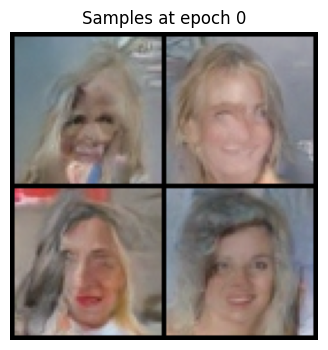

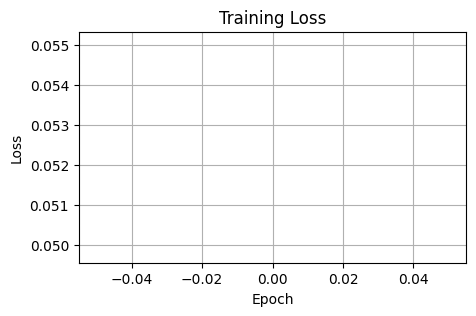

Epoch 2/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1: avg loss = 0.0521


Epoch 3/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2: avg loss = 0.0535


Epoch 4/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 8: avg loss = 0.0525


Epoch 10/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 9: avg loss = 0.0532


Epoch 11/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 10: avg loss = 0.0525


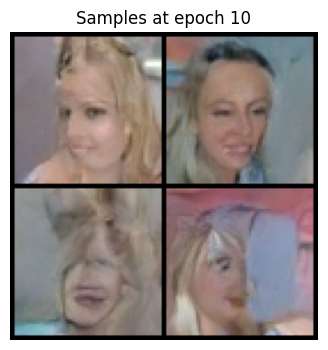

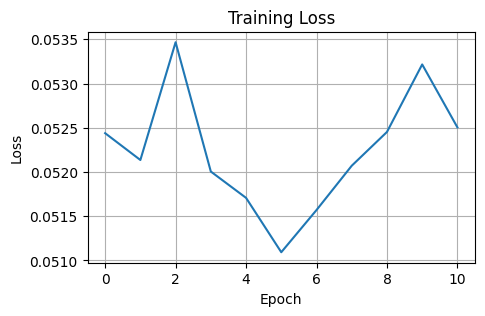

Epoch 12/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 11: avg loss = 0.0511


Epoch 13/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 12: avg loss = 0.0519


Epoch 14/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 18: avg loss = 0.0522


Epoch 20/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 19: avg loss = 0.0516


Epoch 21/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 20: avg loss = 0.0519


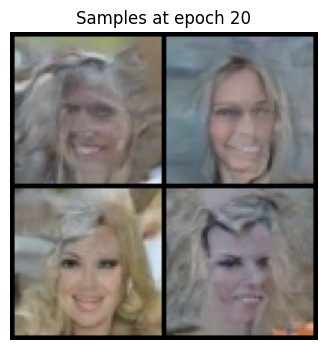

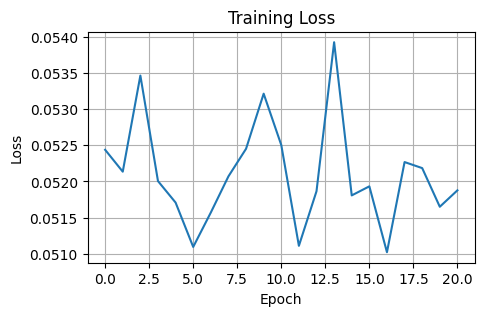

Epoch 22/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 21: avg loss = 0.0525


Epoch 23/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 22: avg loss = 0.0519


Epoch 24/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 28: avg loss = 0.0507


Epoch 30/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 29: avg loss = 0.0505


Epoch 31/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 30: avg loss = 0.0529


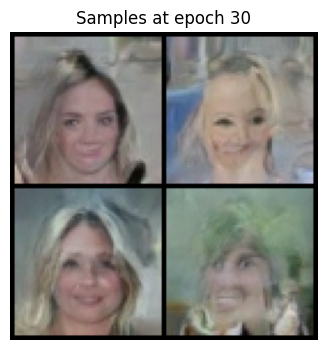

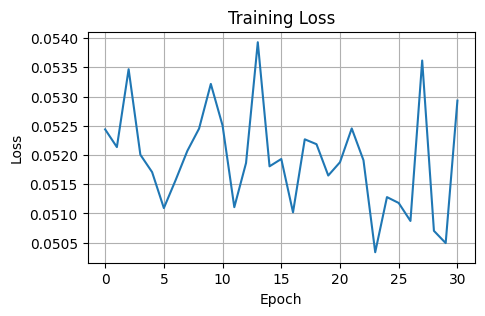

Epoch 32/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 31: avg loss = 0.0500


Epoch 33/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 32: avg loss = 0.0512


Epoch 34/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 38: avg loss = 0.0507


Epoch 40/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 39: avg loss = 0.0510


Epoch 41/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 40: avg loss = 0.0511


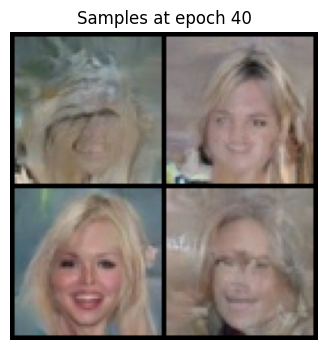

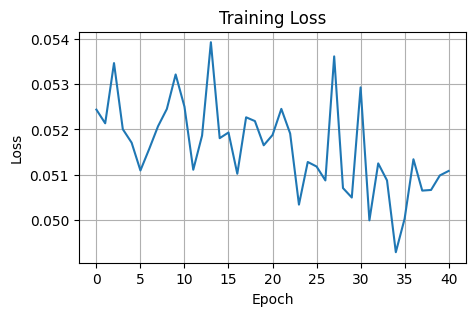

Epoch 42/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 41: avg loss = 0.0505


Epoch 43/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 42: avg loss = 0.0490


Epoch 44/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 48: avg loss = 0.0510


Epoch 50/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 49: avg loss = 0.0486


Epoch 51/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 50: avg loss = 0.0496


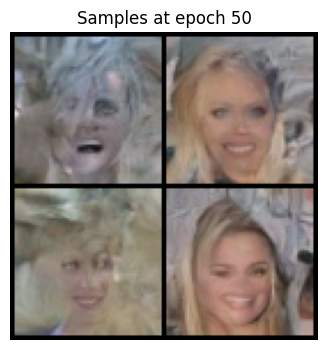

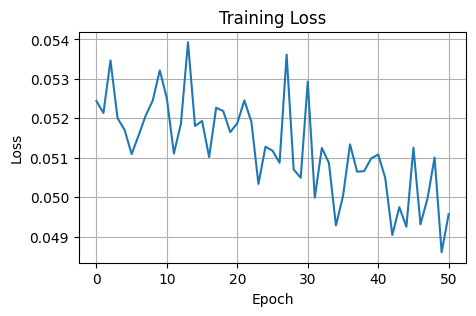

Epoch 52/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 51: avg loss = 0.0515


Epoch 53/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 52: avg loss = 0.0498


Epoch 54/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 58: avg loss = 0.0485


Epoch 60/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 59: avg loss = 0.0503


Epoch 61/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 60: avg loss = 0.0496


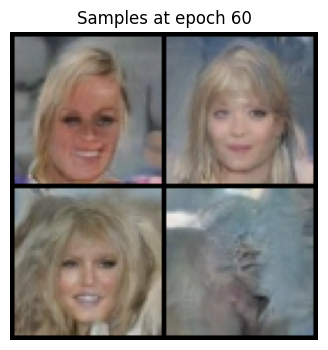

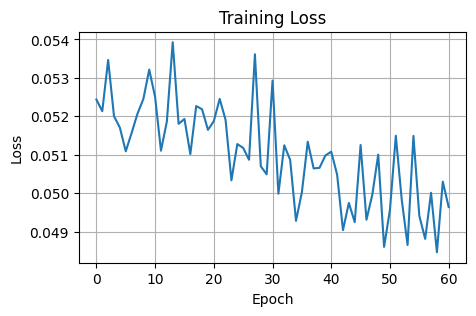

Epoch 62/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 61: avg loss = 0.0485


Epoch 63/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 62: avg loss = 0.0481


Epoch 64/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 68: avg loss = 0.0496


Epoch 70/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 69: avg loss = 0.0488


Epoch 71/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 70: avg loss = 0.0502


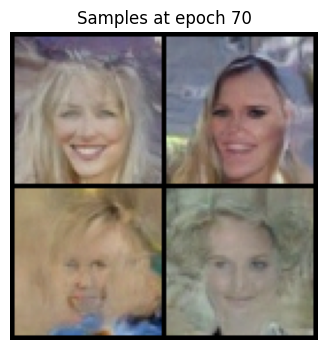

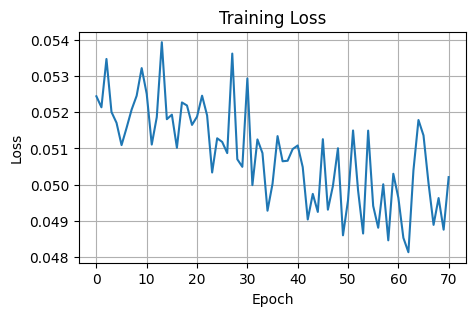

Epoch 72/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 71: avg loss = 0.0496


Epoch 73/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 72: avg loss = 0.0491


Epoch 74/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 78: avg loss = 0.0489


Epoch 80/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 79: avg loss = 0.0506


Epoch 81/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 80: avg loss = 0.0495


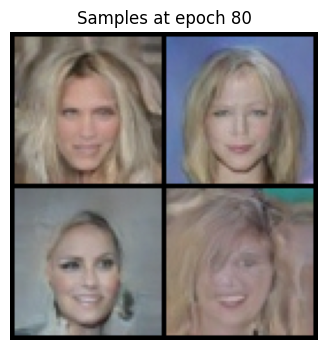

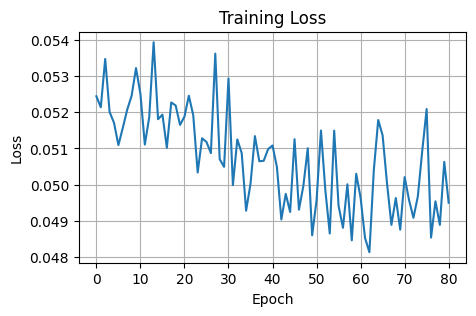

Epoch 82/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 81: avg loss = 0.0469


Epoch 83/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 82: avg loss = 0.0491


Epoch 84/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 88: avg loss = 0.0482


Epoch 90/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 89: avg loss = 0.0486


Epoch 91/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 90: avg loss = 0.0492


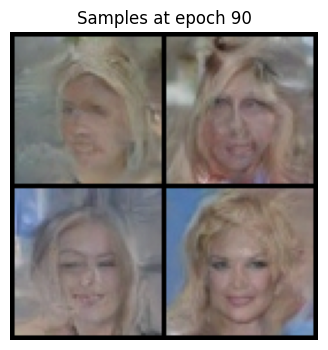

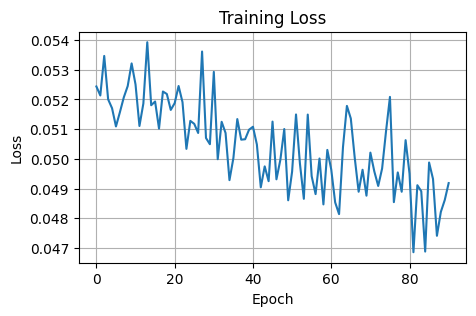

Epoch 92/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 91: avg loss = 0.0473


Epoch 93/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 92: avg loss = 0.0480


Epoch 94/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 98: avg loss = 0.0491


Epoch 100/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 99: avg loss = 0.0471


Epoch 101/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 100: avg loss = 0.0492


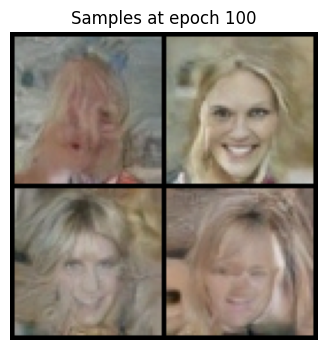

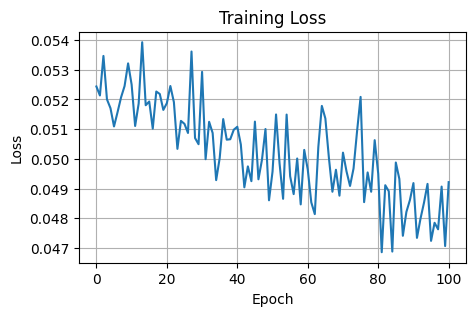

Epoch 102/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 101: avg loss = 0.0495


Epoch 103/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 102: avg loss = 0.0487


Epoch 104/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 108: avg loss = 0.0462


Epoch 110/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 109: avg loss = 0.0468


Epoch 111/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 110: avg loss = 0.0465


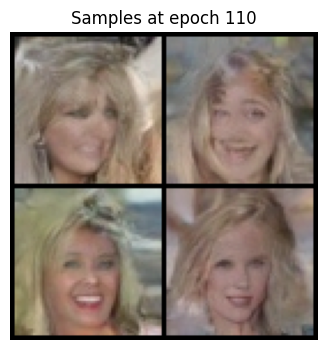

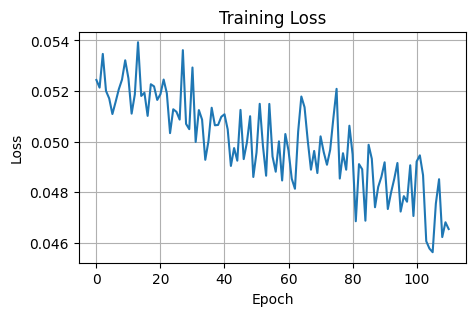

Epoch 112/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 111: avg loss = 0.0469


Epoch 113/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 112: avg loss = 0.0457


Epoch 114/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 118: avg loss = 0.0474


Epoch 120/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 119: avg loss = 0.0471


Epoch 121/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 120: avg loss = 0.0469


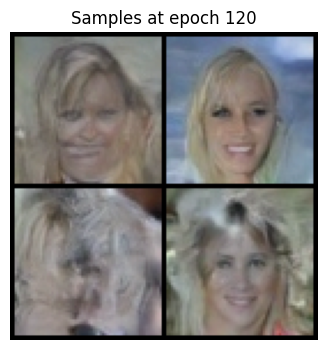

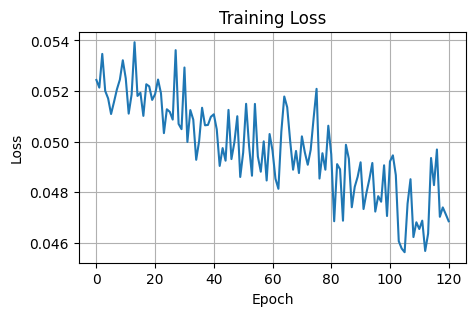

Epoch 122/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 121: avg loss = 0.0482


Epoch 123/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 122: avg loss = 0.0469


Epoch 124/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 128: avg loss = 0.0453


Epoch 130/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 129: avg loss = 0.0467


Epoch 131/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 130: avg loss = 0.0479


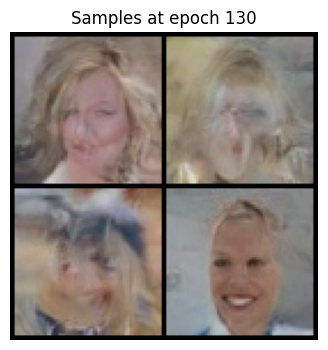

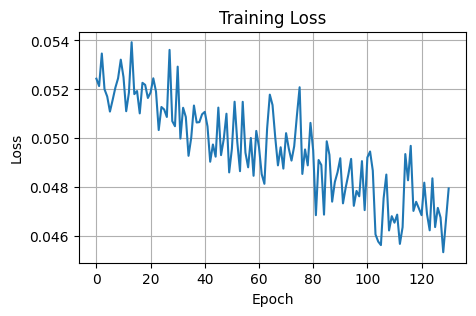

Epoch 132/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 131: avg loss = 0.0479


Epoch 133/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 132: avg loss = 0.0470


Epoch 134/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 138: avg loss = 0.0483


Epoch 140/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 139: avg loss = 0.0481


Epoch 141/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 140: avg loss = 0.0464


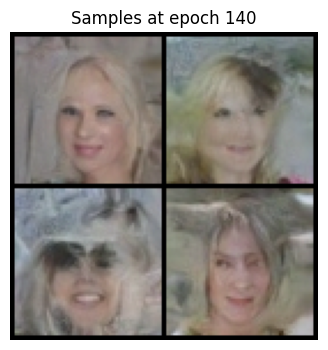

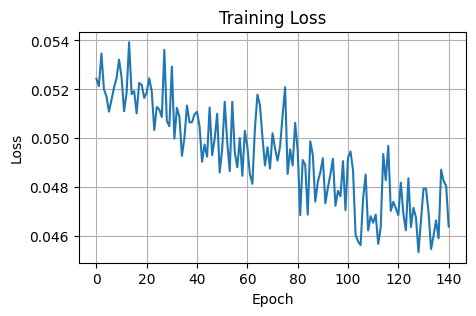

Epoch 142/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 141: avg loss = 0.0459


Epoch 143/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 142: avg loss = 0.0483


Epoch 144/150:   0%|          | 0/250 [00:00<?, ?it/s]

...

Epoch 147: avg loss = 0.0468


Epoch 149/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 148: avg loss = 0.0464


Epoch 150/150:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 149: avg loss = 0.0453


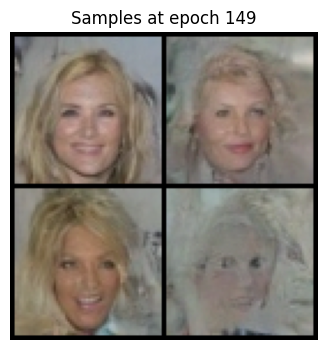

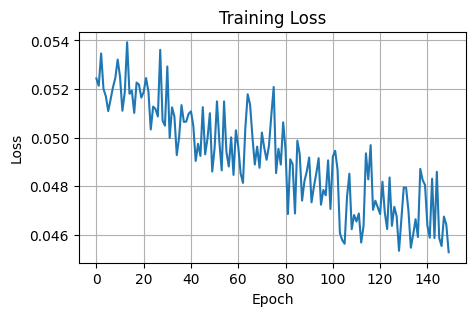

In [71]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from IPython.display import display
import torch.nn.functional as F
import os

EPOCHS = 150
SAMPLE_EVERY = 10
CHECKPOINT_DIR = "/workspace/weights/with_self_attention"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

loss_history = []

model.train()

@torch.no_grad()
def update_ema(model, ema_model, decay=0.999):
    for p, p_ema in zip(model.parameters(), ema_model.parameters()):
        p_ema.data.mul_(decay).add_(p.data, alpha=1 - decay)

for epoch in range(EPOCHS):
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    epoch_loss = 0.0

    for x0, _ in pbar:
        x0 = x0.to(device)

        # sample timestep
        t = torch.randint(0, ddpm.T, (x0.size(0),), device=device)

        # forward diffusion
        noise = torch.randn_like(x0)
        x_t = ddpm.q_sample(x0, t, noise)

        # -----------------------------
        # v-prediction (ONLY THIS)
        # -----------------------------
        v_pred = model(x_t, t)

        alpha_t = extract(ddpm.alpha_bar.sqrt(), t, x0.shape)
        sigma_t = extract((1 - ddpm.alpha_bar).sqrt(), t, x0.shape)

        v_target = alpha_t * noise - sigma_t * x0

        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_ema(model, ema_model)

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch}: avg loss = {avg_loss:.4f}")

    # -----------------------------
    # Sampling + checkpoint
    # -----------------------------
    if epoch % SAMPLE_EVERY == 0 or epoch == EPOCHS - 1:
        torch.save(
            {
                "epoch": epoch,
                "ema_model_state": ema_model.state_dict(),
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "loss_history": loss_history,
            },
            os.path.join(CHECKPOINT_DIR, f"ddpm_epoch_{epoch}.pt")
        )

        ema_model.eval()
        with torch.no_grad():
            samples = ddpm.sample(ema_model, n=4)
            samples = (samples.clamp(-1, 1) + 1) / 2
            grid = make_grid(samples, nrow=2)

            plt.figure(figsize=(4, 4))
            plt.imshow(grid.permute(1, 2, 0).cpu())
            plt.axis("off")
            plt.title(f"Samples at epoch {epoch}")
            display(plt.gcf())
            plt.close()

            plt.figure(figsize=(5, 3))
            plt.plot(loss_history)
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title("Training Loss")
            plt.grid(True)
            display(plt.gcf())
            plt.close()

        model.train()

Loading checkpoint: /workspace/weights/with_self_attention/ddpm_epoch_149.pt
✓ Found EMA weights in checkpoint
EMA model loaded successfully


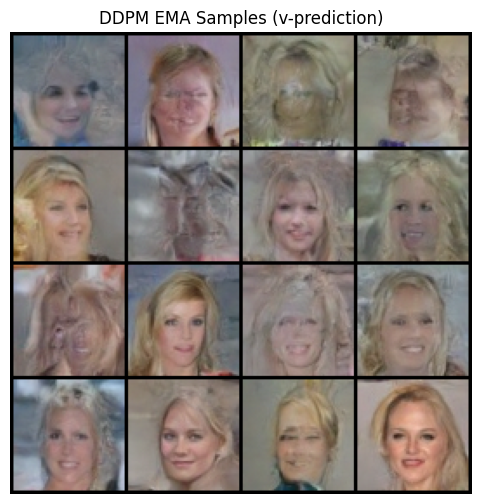

In [74]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# =====================================================
# CONFIG
# =====================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH = "/workspace/weights/with_self_attention/ddpm_epoch_149.pt"
NUM_SAMPLES = 16

# =====================================================
# RECREATE MODEL & DDPM (MUST MATCH TRAINING)
# =====================================================
model = UNet64().to(device)

ddpm = DDPM(
    T=500,
    beta_start=1e-4,
    beta_end=1e-2,
    device=device
)

# =====================================================
# LOAD CHECKPOINT CORRECTLY
# =====================================================
print(f"Loading checkpoint: {CHECKPOINT_PATH}")

ckpt = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

# -----------------------------------------------------
# LOAD EMA WEIGHTS (THIS IS THE IMPORTANT PART)
# -----------------------------------------------------
if "ema_model_state" in ckpt:
    print("✓ Found EMA weights in checkpoint")
    model.load_state_dict(ckpt["ema_model_state"])
else:
    raise RuntimeError("Checkpoint does not contain EMA weights!")

model.eval()
print("EMA model loaded successfully")

# =====================================================
# SAMPLING FUNCTION (v-PREDICTION CORRECT)
# =====================================================
@torch.no_grad()
def sample_v_prediction(ddpm, model, n):
    x = torch.randn(n, 3, 64, 64, device=device)

    for i in reversed(range(ddpm.T)):
        t = torch.full((n,), i, device=device)

        # model predicts v
        v = model(x, t)

        alpha_t = torch.sqrt(ddpm.alpha_bar[i])
        sigma_t = torch.sqrt(1 - ddpm.alpha_bar[i])

        # recover epsilon from v
        eps = alpha_t * v + sigma_t * x

        # reverse diffusion step
        x = (x - (1 - ddpm.alphas[i]) / torch.sqrt(1 - ddpm.alpha_bar[i]) * eps) \
            / torch.sqrt(ddpm.alphas[i])

        if i > 0:
            x += torch.sqrt(ddpm.betas[i]) * torch.randn_like(x)

    return x

# =====================================================
# GENERATE SAMPLES (THIS IS THE TEST)
# =====================================================
with torch.no_grad():
    samples = sample_v_prediction(ddpm, model, NUM_SAMPLES)
    samples = (samples.clamp(-1, 1) + 1) / 2

# =====================================================
# VISUALIZE
# =====================================================
grid = make_grid(samples, nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("DDPM EMA Samples (v-prediction)")
plt.show()
